In [112]:
import os
import pandas as pd
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [113]:
load_dotenv(override=True)

file_path = os.getenv('LOAD_CLEAN_PATH')

if not file_path:
    file_path = '/content/cleaned.csv'

In [114]:
try:
    df = pd.read_csv(file_path)
except FileExistsError:
    raise Exception('CRITICAL: File path not found')

### Mapping columns `Compund` and `Rainfall` for Regression model

In [115]:
df['Compound'] = df['Compound'].map({'INTERMEDIATE': 0, 'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'WET': 4})
df['TyreLife_Sq'] = df['TyreLife'] ** 2

Text(0.5, 1.0, 'F1 Feature Correlation Matrix')

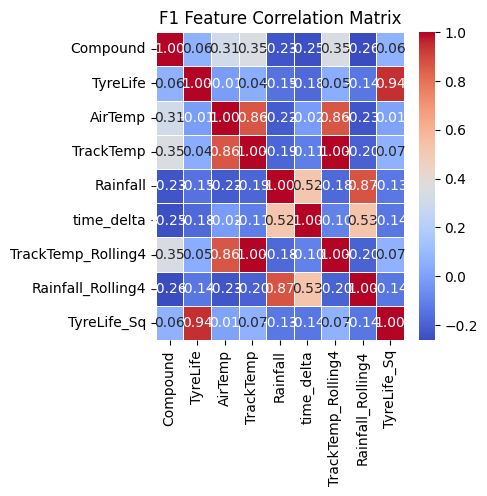

In [116]:
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
ax.set_title('F1 Feature Correlation Matrix')

Text(0.5, 1.0, 'Tire Drop-off by Age and Compound')

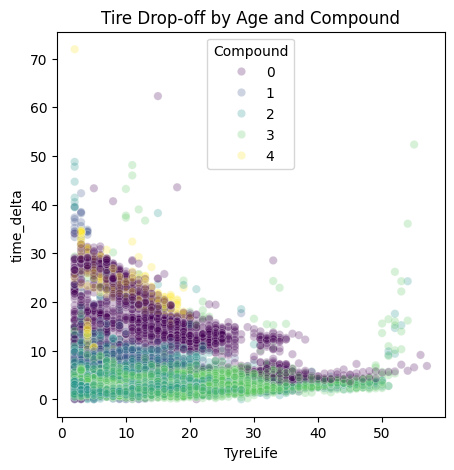

In [117]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data=df, x='TyreLife', y='time_delta', hue='Compound', palette='viridis', alpha=0.25)
ax.set_title('Tire Drop-off by Age and Compound')

Text(0.5, 1.0, 'Rainfall vs Pace')

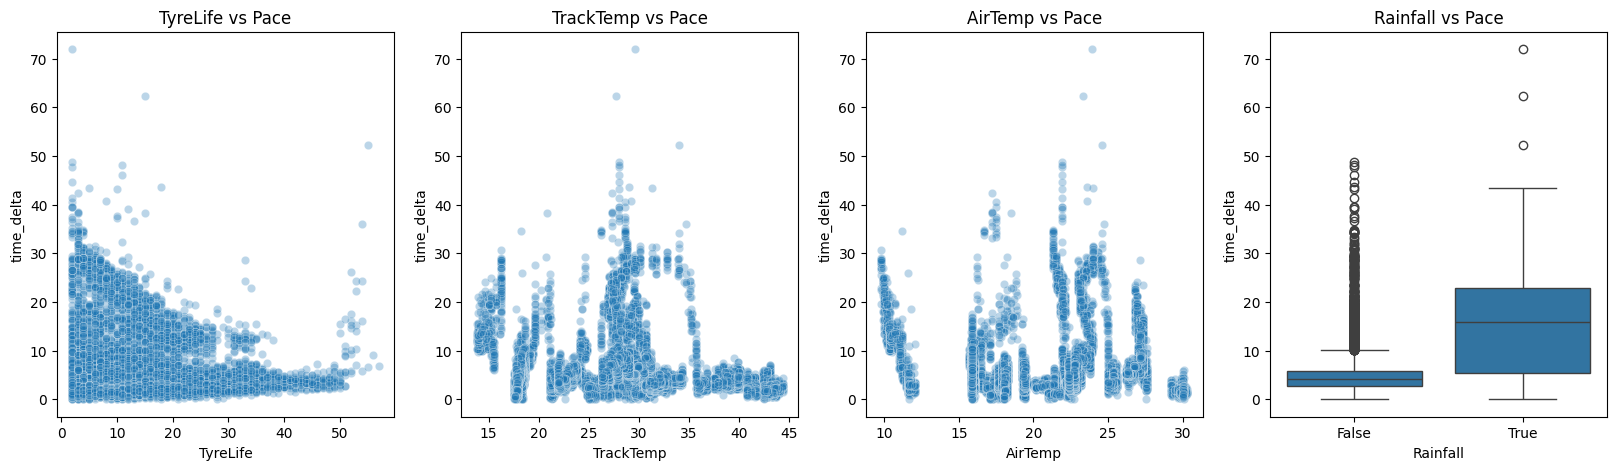

In [118]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.scatterplot(data=df, x='TyreLife', y='time_delta', ax=axes[0], alpha=0.3)
axes[0].set_title('TyreLife vs Pace')

sns.scatterplot(data=df, x='TrackTemp', y='time_delta', ax=axes[1], alpha=0.3)
axes[1].set_title('TrackTemp vs Pace')

sns.scatterplot(data=df, x='AirTemp', y='time_delta', ax=axes[2], alpha=0.3)
axes[2].set_title('AirTemp vs Pace')

sns.boxplot(data=df, x='Rainfall', y='time_delta', ax=axes[3])
axes[3].set_title('Rainfall vs Pace')

### Fixing *Compound Compound Encoding quirk*
Due to mapping categorical 'Compound' data to integers, the correlation getting disturbed

In [119]:
df = pd.get_dummies(df, columns=['Compound'])

In [120]:
X = df.drop(columns=['time_delta', 'TyreLife'])
y = df['time_delta']

In [121]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f'Training on {len(X_train)} historical laps.')
print(f'Testing on {len(X_test)} historical laps.')

Training on 10936 historical laps.
Testing on 2734 historical laps.


In [122]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

In [123]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [124]:
y_pred = model.predict(X_test)

In [125]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)

In [126]:
print(f'Root Mean Squared Error (RMSE) = {rmse:.6f}')
print(f'Mean Absolute Error (MAE)      = {mae:.6f}')

Root Mean Squared Error (RMSE) = 2.797148
Mean Absolute Error (MAE)      = 2.372963
